# 03 · Error analysis of the final models on test

What the detectors of phase 2 miss on the test split (9–10 Sep 2022), and what they alert in vain.

- The models are the families of `config/models.yaml` v1.3, refit on train + validation (ADR-0014).
- The scores come from `make holdout` (`data/reports/holdout_scores.parquet`): this notebook scores nothing and fits nothing.
- The test split is read once per reported result (ADR-0005). This notebook describes that result in more detail; **no rule, feature or model changes because of it**.
- The protocol is ADR-0007's: an alert is an account-day, and models get as many alerts a day as the rules raised.

Run it with `make notebook` (needs `make holdout`). The data is synthetic: nothing here says how the models would do on real transactions.

In [1]:
import os
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from atalayero.models.evaluate import AlertMetrics, SplitEvaluator
from atalayero.rules.schema import load_rules
from atalayero.settings import Settings

# Settings and data paths are relative to the repository root.
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
pd.set_option("display.precision", 1)
# Categorical slots 1-3 of the dataviz reference palette (CVD-safe as a set); ink stays neutral.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
MUTED = "#8b8a86"
plt.rcParams.update(
    {
        "figure.dpi": 90,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": "#52514e",
        "xtick.color": "#52514e",
        "ytick.color": "#52514e",
        "axes.grid": True,
        "grid.color": "#e6e5e1",
        "grid.linewidth": 0.8,
        "axes.axisbelow": True,
    }
)

## The detectors on test

The rules alert at their own volume. LightGBM, the family chosen on validation, gets the rules' volume day by day, and also 400 alerts a day.

In [2]:
settings = Settings()
scores = duckdb.read_parquet(str(settings.evaluation.reports_dir / "holdout_scores.parquet")).df()
evaluator = SplitEvaluator(settings, "test")

runs: dict[str, tuple[AlertMetrics, pd.DataFrame, pd.DataFrame]] = {}
rules = evaluator.evaluate_rules(settings.rule_alerts_dir, load_rules(settings.rules_dir))
runs["rules"] = (rules, evaluator.detections(), evaluator.alerts())
budget = evaluator.rule_budget()
evaluator.set_scores(scores["transaction_id"].to_numpy(), scores["lightgbm"].to_numpy())
for name, size in [("lightgbm", budget), ("lightgbm @ 400/day", 400)]:
    metrics = evaluator.evaluate_scores(name, size)
    runs[name] = (metrics, evaluator.detections(), evaluator.alerts())

pd.DataFrame(
    {
        name: {
            "alerts a day": m.alerts_per_day,
            "detection %": 100 * m.laundering.rate,
            "without hubs %": 100 * m.laundering_without_hubs.rate,
            "false positives %": 100 * m.false_positive_share,
            "alerts on hubs %": 100 * m.hub_alert_share,
            "attempts": f"{m.attempts.covered}/{m.attempts.total}",
        }
        for name, (m, _, _) in runs.items()
    }
).T

,alerts a day,detection %,without hubs %,false positives %,alerts on hubs %,attempts
rules,85.5,19.4,7.8,70.2,17.5,45/174
lightgbm,85.5,21.1,21.1,0.6,0.0,72/174
lightgbm @ 400/day,400.0,47.5,47.5,32.6,0.0,140/174


## 1 · What is missed, by typology

Share of each group's laundering transactions that are detected. For the rules, "without hubs" leaves out what they detect only through one of the 15 hub accounts (ADR-0007); LightGBM puts no alert on hubs, so both columns are the same for it.

,transactions,rules,rules without hubs,lightgbm,lightgbm @ 400/day
typology,,,,,
(untyped),371,30.2,0.5,0.0,0.3
stack,84,3.6,3.6,6.0,58.3
bipartite,44,9.1,9.1,9.1,34.1
fan_out,65,6.2,6.2,29.2,87.7
fan_in,57,5.3,5.3,29.8,84.2
cycle,55,18.2,18.2,38.2,85.5
gather_scatter,127,14.2,14.2,44.9,81.1
scatter_gather,110,22.7,22.7,50.9,89.1
random,43,14.0,14.0,53.5,83.7


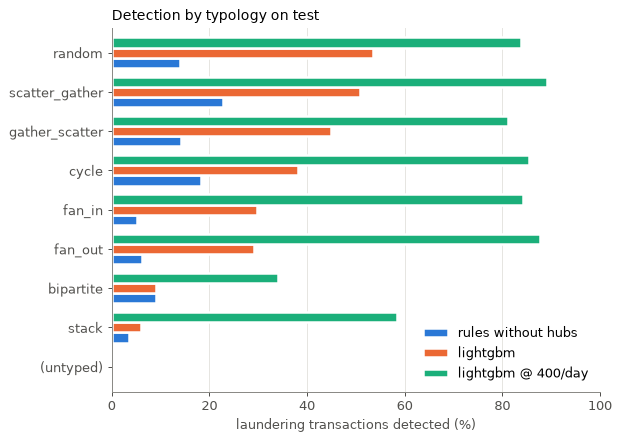

In [3]:
def by_group(detections: pd.DataFrame, column: str) -> pd.Series:
    """Detection rate in % per typology, with untyped laundering as its own group."""
    group = detections["typology"].fillna("(untyped)")
    return 100 * detections.groupby(group)[column].mean()


rule_detections = runs["rules"][1]
groups = pd.DataFrame(
    {
        "transactions": rule_detections["typology"].fillna("(untyped)").value_counts(),
        "rules": by_group(rule_detections, "detected"),
        "rules without hubs": by_group(rule_detections, "via_other_than_hub"),
        "lightgbm": by_group(runs["lightgbm"][1], "detected"),
        "lightgbm @ 400/day": by_group(runs["lightgbm @ 400/day"][1], "detected"),
    }
).sort_values("lightgbm")
display(groups)

shown = groups.drop(columns=["transactions", "rules"])
ax = shown.plot.barh(figsize=(7, 5), width=0.78, color=SERIES, edgecolor="white", linewidth=2)
ax.set_xlabel("laundering transactions detected (%)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.legend(frameon=False, loc="lower right")
ax.set_title("Detection by typology on test", loc="left", fontsize=11)
plt.tight_layout()

## 2 · Untyped laundering

Laundering that belongs to no documented attempt (ADR-0002). How LightGBM scores it, against patterned laundering and clean transactions, and how large a daily budget would have to be to reach it.

,transactions,median,p90,p99
label_group,,,,
clean,861836,1.65e-05,1.50e-03,1.74e-02
patterned,585,4.99e-01,9.82e-01,9.97e-01
untyped,371,6.02e-03,4.88e-02,1.72e-01


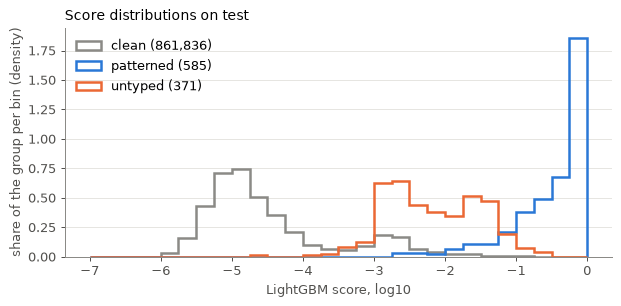

In [4]:
labels = scores.merge(
    runs["lightgbm"][1][["transaction_id", "label_group"]], on="transaction_id", how="left"
).fillna({"label_group": "clean"})
quantiles = labels.groupby("label_group")["lightgbm"].quantile([0.5, 0.9, 0.99]).unstack()
quantiles.columns = ["median", "p90", "p99"]
quantiles.insert(0, "transactions", labels["label_group"].value_counts())
display(
    quantiles.astype({"transactions": int}).map(lambda v: f"{v:.2e}" if isinstance(v, float) else v)
)

fig, ax = plt.subplots(figsize=(7, 3.5))
bins = [x / 4 for x in range(-28, 1)]  # log10 of the score, in quarters of a decade
for group, color in [("clean", MUTED), ("patterned", SERIES[0]), ("untyped", SERIES[1])]:
    values = labels.loc[labels["label_group"] == group, "lightgbm"].clip(lower=1e-7)
    ax.hist(
        np.log10(values),
        bins=bins,
        density=True,
        histtype="step",
        linewidth=2,
        label=f"{group} ({len(values):,})",
        color=color,
    )
ax.set_xlabel("LightGBM score, log10")
ax.set_ylabel("share of the group per bin (density)")
ax.grid(axis="x", visible=False)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Score distributions on test", loc="left", fontsize=11)
plt.tight_layout()

In [5]:
budgets = [85, 200, 400, 1000, 2000, 5000, 10000]
reach = []
for size in budgets:
    m = evaluator.evaluate_scores(f"lightgbm @ {size}/day", size)
    reach.append(
        {
            "alerts a day": size,
            "patterned %": 100 * m.patterned.rate,
            "untyped %": 100 * m.untyped.rate,
            "false positives %": 100 * m.false_positive_share,
        }
    )
pd.DataFrame(reach).set_index("alerts a day")

,patterned %,untyped %,false positives %
alerts a day,,,
85,34.4,0.0,0.0
200,61.0,0.0,8.2
400,77.4,0.3,32.6
1000,89.4,4.6,63.9
2000,93.2,13.7,79.0
5000,96.9,43.4,89.8
10000,98.5,68.7,94.0


In [6]:
untyped = runs["lightgbm"][1].assign(group=lambda d: d["label_group"])
formats = pd.crosstab(untyped["payment_format"], untyped["group"], normalize="columns") * 100
formats.loc["median amount (USD)"] = untyped.groupby("group")["amount_paid_usd"].median()
formats

group,patterned,untyped
payment_format,,
ach,99.8,67.4
bitcoin,0.2,2.4
cash,0.0,5.1
cheque,0.0,16.2
credit_card,0.0,8.9
median amount (USD),10421.9,2407.9


## 3 · False positives

Alerted account-days with no laundering of that account on that day. LightGBM barely has any at the rules' volume, so its false positives are looked at with 400 alerts a day.

In [7]:
def false_positives(alerts: pd.DataFrame) -> dict[str, float]:
    wrong = alerts[~alerts["has_laundering"]]
    right = alerts[alerts["has_laundering"]]
    return {
        "alerts": len(alerts),
        "false positives": len(wrong),
        "of them on hubs": int(wrong["on_hub"].sum()),
        "median transactions, false positive": wrong["transactions"].median(),
        "median transactions, true positive": right["transactions"].median(),
    }


pd.DataFrame({name: false_positives(alerts) for name, (_, _, alerts) in runs.items()}).T

,alerts,false positives,of them on hubs,"median transactions, false positive","median transactions, true positive"
rules,171.0,120.0,9.0,18.0,9.0
lightgbm,171.0,1.0,0.0,3.0,4.0
lightgbm @ 400/day,800.0,261.0,0.0,4.0,3.0


## 4 · Rules and model: the same laundering or different?

Each laundering transaction by who detects it. Rules count with hubs here, as an analyst would see them. This only describes test: a detector that combines both would have to be built and chosen on validation.

In [8]:
both = runs["rules"][1][["transaction_id", "label_group", "detected"]].merge(
    runs["lightgbm"][1][["transaction_id", "detected"]],
    on="transaction_id",
    suffixes=("_rules", "_model"),
)
who = both["detected_rules"].map({True: "rules", False: ""}) + both["detected_model"].map(
    {True: " + model", False: ""}
)
who = who.str.strip(" +").replace(
    {"rules + model": "both", "": "neither", "model": "model only", "rules": "rules only"}
)
pd.crosstab(who.rename("detected by"), both["label_group"], margins=True)

label_group,patterned,untyped,All
detected by,,,
both,58,0,58
model only,144,0,144
neither,368,259,627
rules only,15,112,127
All,585,371,956


## 5 · By day

Test mixes a busy Friday with a quiet Saturday, and drift monitoring flags the Saturday on two graph features because of its weekend reference (ADR-0014).

In [9]:
per_day = []
for name, (_, detections, alerts) in runs.items():
    day = detections["transacted_at"].dt.date
    for d, group in detections.groupby(day):
        per_day.append(
            {
                "detector": name,
                "day": d,
                "laundering": len(group),
                "detected %": 100 * group["detected"].mean(),
                "without hubs %": 100 * group["via_other_than_hub"].mean(),
                "alerts": int((alerts["day"].dt.date == d).sum()),
            }
        )
pd.DataFrame(per_day).set_index(["detector", "day"])

laundering  detected %  without hubs %  alerts
detector           day                                                       
rules              2022-09-09         514        22.2             5.3     110
                   2022-09-10         442        16.1            10.9      61
lightgbm           2022-09-09         514        25.1            25.1     110
                   2022-09-10         442        16.5            16.5      61
lightgbm @ 400/day 2022-09-09         514        42.8            42.8     400
                   2022-09-10         442        52.9            52.9     400

## Takeaways

These describe the single test run. None of them feeds back into the rules, the features or the models of phase 2.

1. **At the rules' volume, LightGBM detects 21.1% of the laundering without hubs against the rules' 7.8%**, with 1 false positive out of 171 alerts against the rules' 120.
2. **Untyped laundering is out of reach.** LightGBM detects none of its 371 transactions at the rules' volume.
   - It scores them well above clean transactions (median 6.0e-3 against 1.7e-5) but far below patterned laundering (median 0.50).
   - Reaching 43% of it would take 5,000 alerts a day, 90% of them false positives.
   - It looks different from the documented attempts: 67% ACH against 99.8%, with cheques, credit cards and cash, and a median of 2.4k USD against 10.4k.
   - The rules flag 112 of these transactions, but 110 of those only through hubs.
3. **Stack and bipartite are the weakest typologies** at the rules' volume (6.0% and 9.1%). At 400 alerts a day, stack climbs to 58% while bipartite stays at 34%.
4. **The false positives differ in kind.**
   - The rules' false positives are busy account-days: a median of 18 transactions, against 9 for the account-days that do hold laundering.
   - LightGBM's, at 400 alerts a day, are small account-days (a median of 4 transactions), and none is on a hub.
5. **Rules and model mostly catch different laundering.**
   - The model alone catches 144 transactions, the rules alone 127, and both together 58.
   - Of what only the rules catch, 112 transactions are untyped laundering, caught only through hubs. The remaining 15 are patterned.
   - 627 transactions go undetected by both: 368 patterned and 259 untyped.
6. **The Saturday drift does not show up as a loss.**
   - At the rules' volume, detection on 10 Sep falls to 16.5% (25.1% on 9 Sep), following the rules' smaller budget that day (61 alerts against 110).
   - At a fixed 400 alerts a day, Saturday does better: 52.9% against 42.8%.
7. **For phase 3:** untyped laundering is the group where the score gives the agent nothing to start from, so the golden set's second group (laundering without a pattern) will test whether the investigation adds anything beyond the score.